# Ejercicio 1 - Práctica 5

Los exoplanetas o planetas extrasolares son planetas que orbitan alrededor de otras estrellas que se encuentran más allá de nuestro sistema solar. El dataset `exoplanets.csv`, extraído del Archivo de Exoplanetas de la NASA, registra los descubrimientos de exoplanetas que han sido reportados a la fecha en publicaciones científicas revisadas por pares y confirmados utilizando varios métodos de detección y/o técnicas analíticas.

1. El periodo orbital de un exoplaneta (`pl_orbper`) es el tiempo que tarda dicho planeta en dar una vuelta completa alrededor de la estrella que orbita (en días terrestres).

    a) Realice una descripción general de dicha variable que incluya tipo de variable, valores mínimo y máximo que toma y presencia de datos faltantes.

    b) Un astrónomo se propone estudiar la distribución del periodo orbital de los exoplanetas descubiertos hasta la fecha y decide, en primera instancia, representar todos los registros a través de un histograma. Utilizando los valores observados de la variable de interés y unas pocas líneas de código obtiene el siguiente gráfico:

    ![](../../img/image.png)
    
2. ¿Considera que el gráfico anterior es representativo de la distribución real de la variable bajo estudio? ¿Qué podría hacer para mejorarlo?

3. Teniendo en cuenta su respuesta a la pregunta del ítem anterior, realice un histograma para representar la distribución de la variable introduciendo las modificaciones que considere adecuadas. ¿Qué puede decir acerca de la distribución del periodo orbital de los exoplanetas descubiertos?

4. Represente el periodo orbital de nuestro planeta en el gráfico realizado en el ítem anterior y calcule el porcentaje de exoplanetas que poseen años más extensos que el año terrestre.

5. Construya un gráfico que permita visualizar la distribución del número de planetas extrasolares encontrados según año y método de descubrimiento, en el que la variable temporal se encuentre categorizada en lustros (periodos de 5 años). Comente brevemente lo observado.

6. Tomando en cuenta únicamente los exoplanetas descubiertos mediante las técnicas de velocidad radial, tránsito y detección directa, construya un gráfico que le permita visualizar, en forma conjunta, el periodo orbital y la masa (`pl_bmasse`) de los planetas según el método a través del cual se detectaron. ¿Encuentra alguna diferencia en las características de los exoplanetas descubiertos por las distintas técnicas?

7. Johannes Kepler fue un astrónomo y matemático alemán cuya principal contribución científica fue el descubrimiento las leyes que rigen el movimiento de los planetas. Según la Tercera Ley de Kepler del movimiento planetario, el cubo de la distancia media de un planeta a la estrella que éste orbita (D, o semi-eje mayor de la órbita, que equivale a la mitad de la suma de la distancia más grande y la más pequeña a la estrella) es directamente proporcional al cuadrado de su periodo orbital (P): $$D^3 = kP^2$$ Realizando las transformaciones que considere necesarias sobre las variables, verifique gráficamente el cumplimiento de dicha ley para los planetas extrasolares.

---

## Cargamos los datos

In [ ]:
# Cargamos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
# Cargamos el df
# Sacamos las filas que tienen comentarios que comienzan con '#'
data = pd.read_csv("../../datasets/exoplanets.csv", comment="#") 
data.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbsmax,...,st_metratio,st_logg,rastr,ra,decstr,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,1.178,...,[Fe/H],2.45,12h20m42.91s,185.178779,+17d47m35.71s,17.793252,93.1846,4.72307,2.282,4.44038
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,1.530,...,[Fe/H],1.93,15h17m05.90s,229.274595,+71d49m26.19s,71.823943,125.3210,5.01300,1.939,4.56216
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.775,...,[Fe/H],2.55,23h31m17.80s,352.824150,+39d14m09.01s,39.235837,75.4392,5.23133,2.331,4.91781
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1765.03890,2.774,...,[Fe/H],4.45,16h10m24.50s,242.602101,+43d48m58.90s,43.816362,17.9323,6.61935,4.714,6.38300
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.660,...,[Fe/H],4.36,19h41m51.75s,295.465642,+50d31m00.57s,50.516824,21.1397,6.21500,4.651,6.06428


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5787 entries, 0 to 5786
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          5787 non-null   str    
 1   hostname         5787 non-null   str    
 2   sy_snum          5787 non-null   int64  
 3   sy_pnum          5787 non-null   int64  
 4   discoverymethod  5787 non-null   str    
 5   disc_year        5787 non-null   int64  
 6   disc_facility    5787 non-null   str    
 7   pl_controv_flag  5787 non-null   int64  
 8   pl_orbper        5506 non-null   float64
 9   pl_orbsmax       5501 non-null   float64
 10  pl_rade          5766 non-null   float64
 11  pl_radj          5766 non-null   float64
 12  pl_bmasse        5764 non-null   float64
 13  pl_dens          5683 non-null   float64
 14  pl_orbeccen      4950 non-null   float64
 15  pl_insol         4038 non-null   float64
 16  pl_eqt           4294 non-null   float64
 17  st_spectype      2081 non

## Item 1

El periodo orbital de un exoplaneta (`pl_orbper`) es el tiempo que tarda dicho planeta en dar una vuelta completa alrededor de la estrella que orbita (en días terrestres).

a) Realice una descripción general de dicha variable que incluya tipo de variable, valores mínimo y máximo que toma y presencia de datos faltantes.

La variable `pl_orbper` es una variable cuantitativa continua. Más aún,

In [34]:
print('El valor mínimo es:', data['pl_orbper'].max())
print('El valor máximo es:', data['pl_orbper'].min())
print('La cantidad de valores nulos es:', data['pl_orbper'].isnull().sum())

El valor mínimo es: 402000000.0
El valor máximo es: 0.09070629
La cantidad de valores nulos es: 281


## Item 2

¿Considera que el gráfico anterior es representativo de la distribución real de la variable bajo estudio? ¿Qué podría hacer para mejorarlo?

No, el gráfico anterior no es representativo ni útil para analizar la distribución real de la mayoría de los exoplanetas. El problema es que la variable sufre de un sesgo extremo hacia la derecha debido a la presencia de unos pocos valores atípicos muy grandes (apenas se ve en la parte inferior).

Para poder meter esos valores gigantescos en el eje X, el ancho de los intervalos (bins) se vuelve enorme. Alrededor del 99% de los exoplanetas descubiertos tienen periodos orbitales cortos, por lo que terminan todos acumulados y "aplastados" en la mismísima primera barra pegada al cero.

Para mejorarlo podemos aplicar una transformación logarítmica al eje X, la cual comprime las distancias de los valores extremadamente grandes y expande visualmente la región de los periodos cortos.

## Item 3

Teniendo en cuenta su respuesta a la pregunta del ítem anterior, realice un histograma para representar la distribución de la variable introduciendo las modificaciones que considere adecuadas. ¿Qué puede decir acerca de la distribución del periodo orbital de los exoplanetas descubiertos?

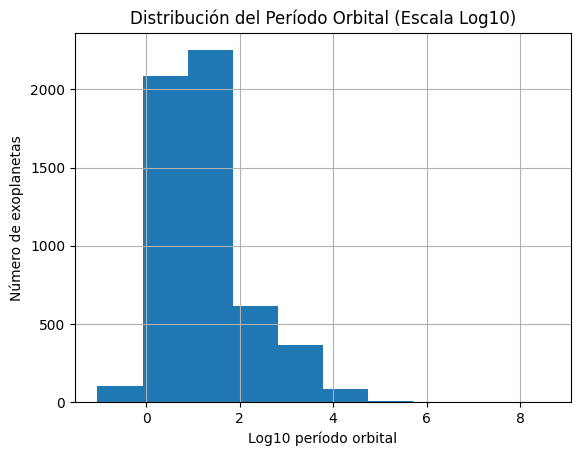

In [44]:
# Creamos una nueva columna con la escala logaritmica
data['log_pl_orbper'] = np.log10(data['pl_orbper'])

# Graficamos un histograma simple
data['log_pl_orbper'].hist()
plt.title('Distribución del Período Orbital (Escala Log10)')
plt.xlabel('Log10 período orbital')
plt.ylabel('Número de exoplanetas')
plt.show()

Se tiene una distribución asimétrica hacia la derecha con una gran concentración en órbitas cortas entre los valores logarítmicos 0 y 4.

## Item 4

Represente el periodo orbital de nuestro planeta en el gráfico realizado en el ítem anterior y calcule el porcentaje de exoplanetas que poseen años más extensos que el año terrestre.

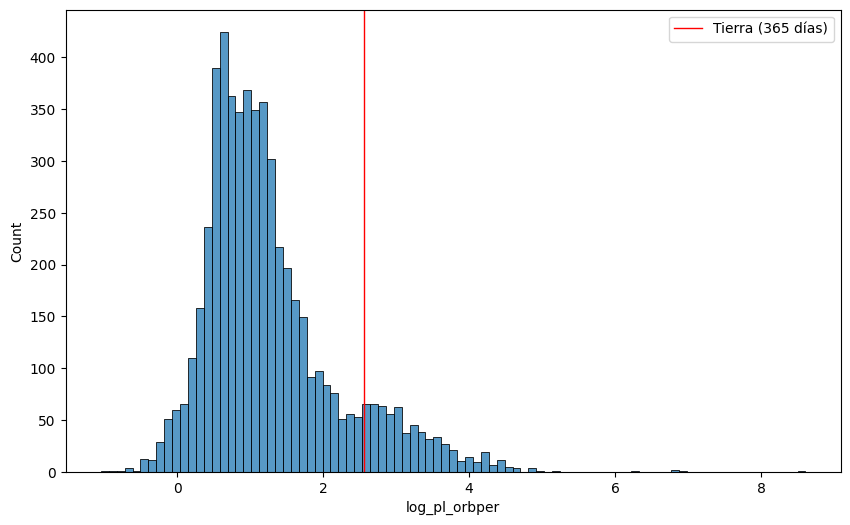

Porcentaje de exoplanetas con año más largo que el de la Tierra: 11.12%


In [50]:
# Graficamos incluyendo la línea de la Tierra (asumiendo el gráfico anterior abierto)
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='log_pl_orbper')
plt.axvline(x=np.log10(365), color='red', linestyle='-', linewidth=1, label='Tierra (365 días)')
plt.legend()
plt.show()

# Calculamos el porcentaje de exoplanetas con años más largos que la Tierra
total_validos = data['pl_orbper'].count()
mas_extensos = data[data['pl_orbper'] > 365.25]['pl_orbper'].count()
porcentaje = (mas_extensos / total_validos) * 100

print(f"Porcentaje de exoplanetas con año más largo que el de la Tierra: {porcentaje:.2f}%")

## Item 5

Construya un gráfico que permita visualizar la distribución del número de planetas extrasolares encontrados según año y método de descubrimiento, en el que la variable temporal se encuentre categorizada en lustros (periodos de 5 años). Comente brevemente lo observado.

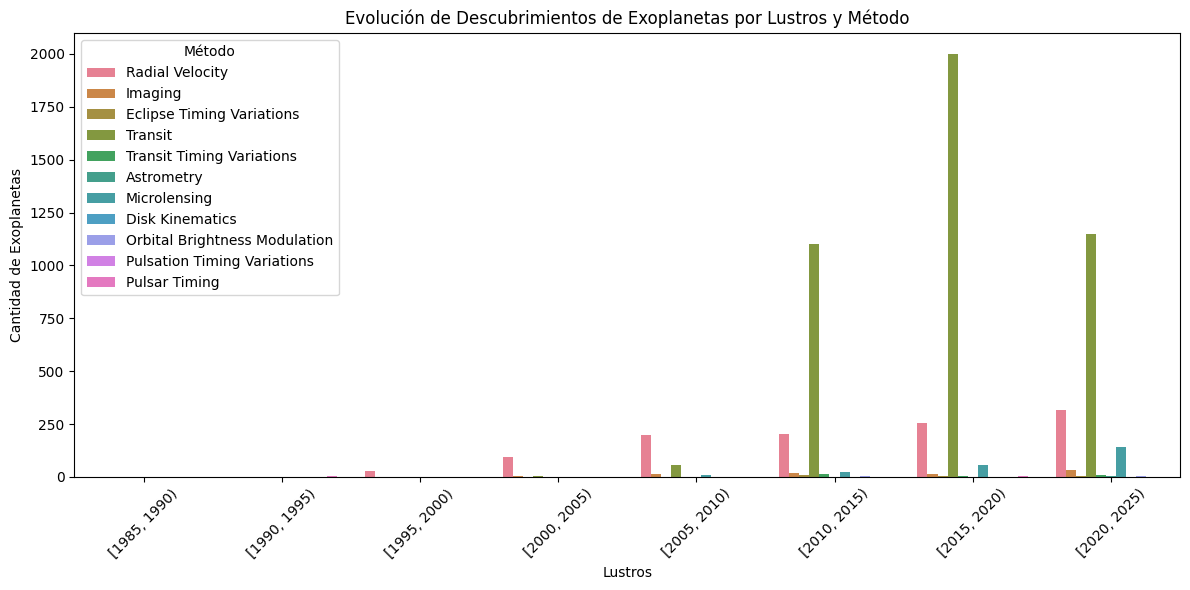

In [52]:
# Creamos la columna de lustros (desde 1985 hasta 2026)
anios_bins = list(range(1985, 2026, 5))
data['lustro'] = pd.cut(data['disc_year'], bins=anios_bins, right=False)

# Graficamos
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='lustro', hue='discoverymethod')
plt.title('Evolución de Descubrimientos de Exoplanetas por Lustros y Método')
plt.xlabel('Lustros')
plt.ylabel('Cantidad de Exoplanetas')
plt.xticks(rotation=45)
plt.legend(title='Método')
plt.tight_layout()
plt.show()

Se nota un crecimiento en los descubrimientos a partir de los lustros 2010-2015 y 2015-2020. Al principio (años 90 y 2000), el método dominante era la velocidad radial, pero a partir de los años 2010-2015 el método de tránsito pasó a monopolizar y disparar el volumen de hallazgos.

# Item 6

Tomando en cuenta únicamente los exoplanetas descubiertos mediante las técnicas de velocidad radial, tránsito y detección directa, construya un gráfico que le permita visualizar, en forma conjunta, el periodo orbital y la masa (`pl_bmasse`) de los planetas según el método a través del cual se detectaron. ¿Encuentra alguna diferencia en las características de los exoplanetas descubiertos por las distintas técnicas?

In [60]:
# Veamos si 'pl_bmasse' asume valores negativos.
print('Valor mínimo:',data['pl_bmasse'].min())


Valor mínimo: 0.02


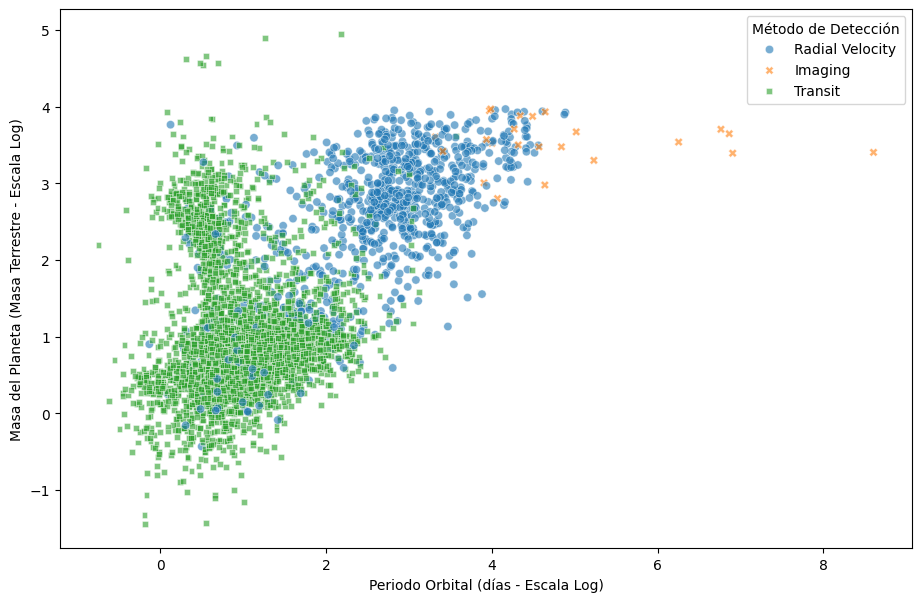

In [55]:
# Calculamos los log10 de la variable pl_bmasse
data['log_pl_bmasse'] = np.log10(data['pl_bmasse'])

# Filtramos por las tres técnicas solicitadas
tecnicas = ['Radial Velocity', 'Transit', 'Imaging']
df_tecnicas = data[data['discoverymethod'].isin(tecnicas)].dropna(subset=['log_pl_orbper', 'log_pl_bmasse'])



# Como tanto el periodo como la masa varían en varios órdenes de magnitud, vamos a graficar
# un Scatter Plot con ambos ejes en escala logarítmica
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_tecnicas, x='log_pl_orbper', y='log_pl_bmasse', hue='discoverymethod', 
                alpha=0.6, style='discoverymethod')

plt.xlabel('Periodo Orbital (días - Escala Log)')
plt.ylabel('Masa del Planeta (Masa Terrestre - Escala Log)')
plt.legend(title='Método de Detección')
plt.show()

Diferencias encontradas por técnica:

- Tránsito: Detecta mayormente planetas con periodos cortos (muchos menores a 100 días) debido a que se requiere ver pasar el planeta varias veces frente a la estrella. Cubre masas variadas, desde planetas rocosos pequeños hasta gigantes gaseosos.

- Velocidad Radial: Tiende a encontrar planetas de masas medianas a altas y con periodos un poco más largos que el tránsito.

- Detección Directa: Solo es capaz de fotografiar planetas que están muy lejos de los destellos de su estrella (periodos extremadamente largos, hacia la derecha del gráfico) y que sean muy masivos (hacia arriba en el gráfico).

## Item 7

Johannes Kepler fue un astrónomo y matemático alemán cuya principal contribución científica fue el descubrimiento las leyes que rigen el movimiento de los planetas. Según la Tercera Ley de Kepler del movimiento planetario, el cubo de la distancia media de un planeta a la estrella que éste orbita (D, o semi-eje mayor de la órbita, que equivale a la mitad de la suma de la distancia más grande y la más pequeña a la estrella) es directamente proporcional al cuadrado de su periodo orbital (P): $$D^3 = kP^2$$ Realizando las transformaciones que considere necesarias sobre las variables, verifique gráficamente el cumplimiento de dicha ley para los planetas extrasolares.

Aplicando $\log$ a ambos miembros se obtiene que $$3\log D = \log k + 2\log P.$$ De donde se obtiene que $$\log D = \frac{1}{3}\log k + \frac{2}{3}\log P.$$ Esto significa que según este modelo si graficamos $\log D$ vs $\log P$, deberíamos ver una línea recta perfecta con una pendiente de $2/3$.

In [61]:
# Veamos si 'pl_orbper' asume valores negativos.
print('Valor mínimo:',data['pl_orbsmax'].min())

Valor mínimo: 0.0044


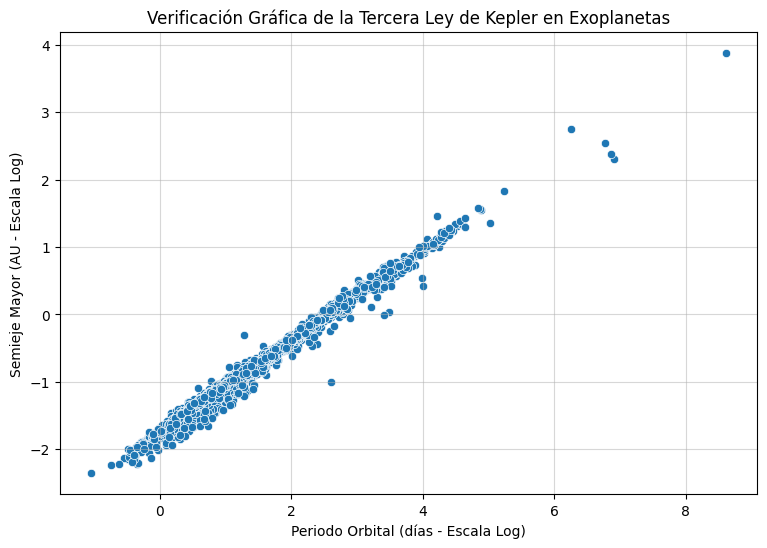

In [67]:
# Calculamos el log10 de 'log_pl_orbsmax'
data['log_pl_orbsmax'] = np.log10(data['pl_orbsmax'])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=data, x='log_pl_orbper', y='log_pl_orbsmax', )

plt.title('Verificación Gráfica de la Tercera Ley de Kepler en Exoplanetas')
plt.xlabel('Periodo Orbital (días - Escala Log)')
plt.ylabel('Semieje Mayor (AU - Escala Log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()